In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from funcs import plot_sensors

In [2]:
PATHOLD = r"C:\Users\User\Desktop\water\data\water_stats.csv"
PATHNEW = r"C:\Users\User\Desktop\water2.csv"
dfold = pd.read_csv(PATHOLD)
df = pd.read_csv(PATHNEW)
regions = {976 : 'Ακταίο', 977: 'Ψαθόπυργος',978: 'Αραχωβίτικα', 979: 'Άγιος Βασίλης',980:'Ρίο',981: 'Καστελλόκαμπος', 982: 'Δάφνες',983: 'Πλάζ', 984:'Ροιτικά'}

df['location'] = df['sensor_id'].map(regions)

df['date_insert'] = pd.to_datetime(df['date_insert'])

In [3]:
SENTINEL_VALUES = [
    9998.01,
    9999.01,
    9999.0,
    -999.0,
    9998.04,
    9991.04,
    9997.03,
    9998.06,
]
CONDUCTIVITY_COL = "conductivity_of_solution_ mS_cm"
ORP_COL = "oxidation_reduction_potential_ mV"
OXYGEN_COL = "oxygen_saturation_%"
TURBIDITY_COL = "turbidity_NTU"

MODEL_FEATURES = [
    CONDUCTIVITY_COL,
    ORP_COL,
    OXYGEN_COL,
    TURBIDITY_COL,
]

HARD_LIMITS = {
    CONDUCTIVITY_COL: (0.0, 100_000.0),
    ORP_COL: (-1_000.0, 1_000.0),
    OXYGEN_COL: (0, 200.0),
    TURBIDITY_COL: (0.1, 1_000.0),
}

In [4]:
for column in MODEL_FEATURES:
    sentinel_mask = pd.Series(
        False,
        index=df.index,
    )

    for sentinel in SENTINEL_VALUES:
        sentinel_mask |= np.isclose(
            df[column],
            sentinel,
            rtol=0.0,
            atol=1e-6,
            equal_nan=False,
        )

    df[f"{column}__sentinel_invalid"] = sentinel_mask
    df.loc[sentinel_mask, column] = np.nan


for column, (lower_limit, upper_limit) in HARD_LIMITS.items():
    hard_limit_mask = (
        df[column].notna()
        & (
            (df[column] < lower_limit)
            | (df[column] > upper_limit)
        )
    )

    df[f"{column}__hard_limit_invalid"] = hard_limit_mask
    df.loc[hard_limit_mask, column] = np.nan

In [5]:
metrics = []
for i in range(9,len(df.columns)-9):
    metrics.append(df.columns[i])
metrics

['wtempV_°C',
 'conductivity_of_solution_ mS_cm',
 'oxidation_reduction_potential_ mV',
 'total_suspended_solids_mg_L',
 'turbidity_NTU',
 'dissolved_oxygen_concentration _ppm',
 'dissolved_oxygen_concentration_mg_L',
 'oxygen_saturation_%',
 'salinity_ppt',
 'dissolved_solids _ppm']

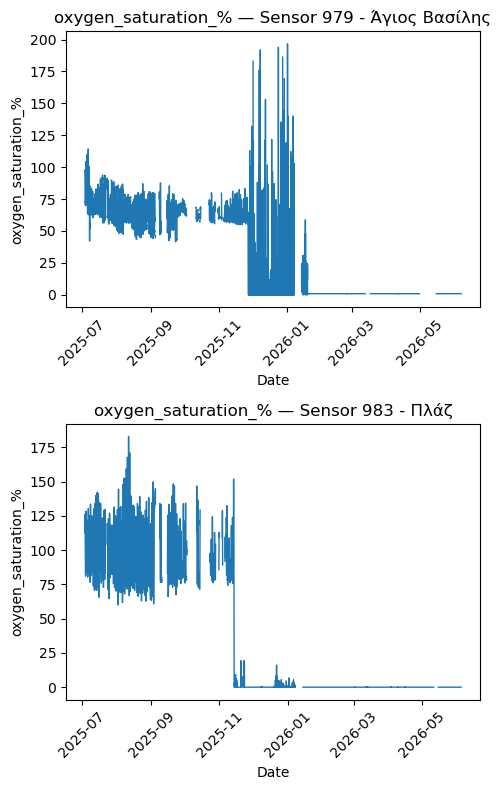

In [9]:
plot_sensors([979,983],[OXYGEN_COL],df)

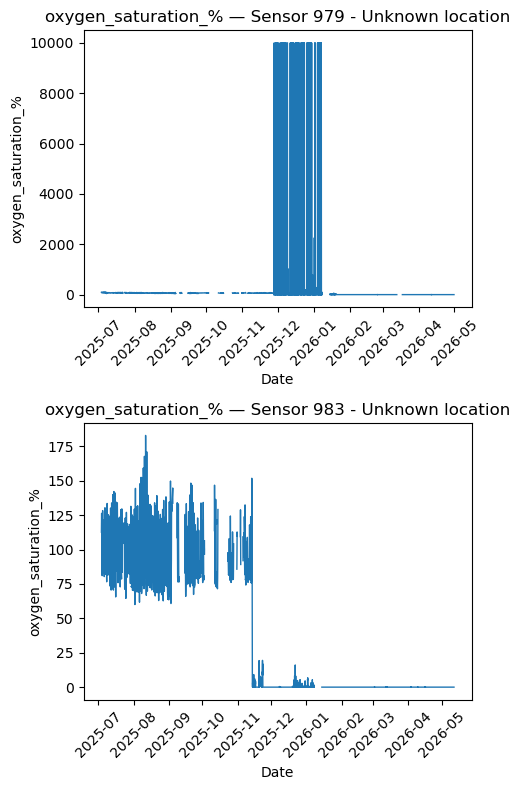

In [10]:
plot_sensors([979,983],[OXYGEN_COL],dfold)

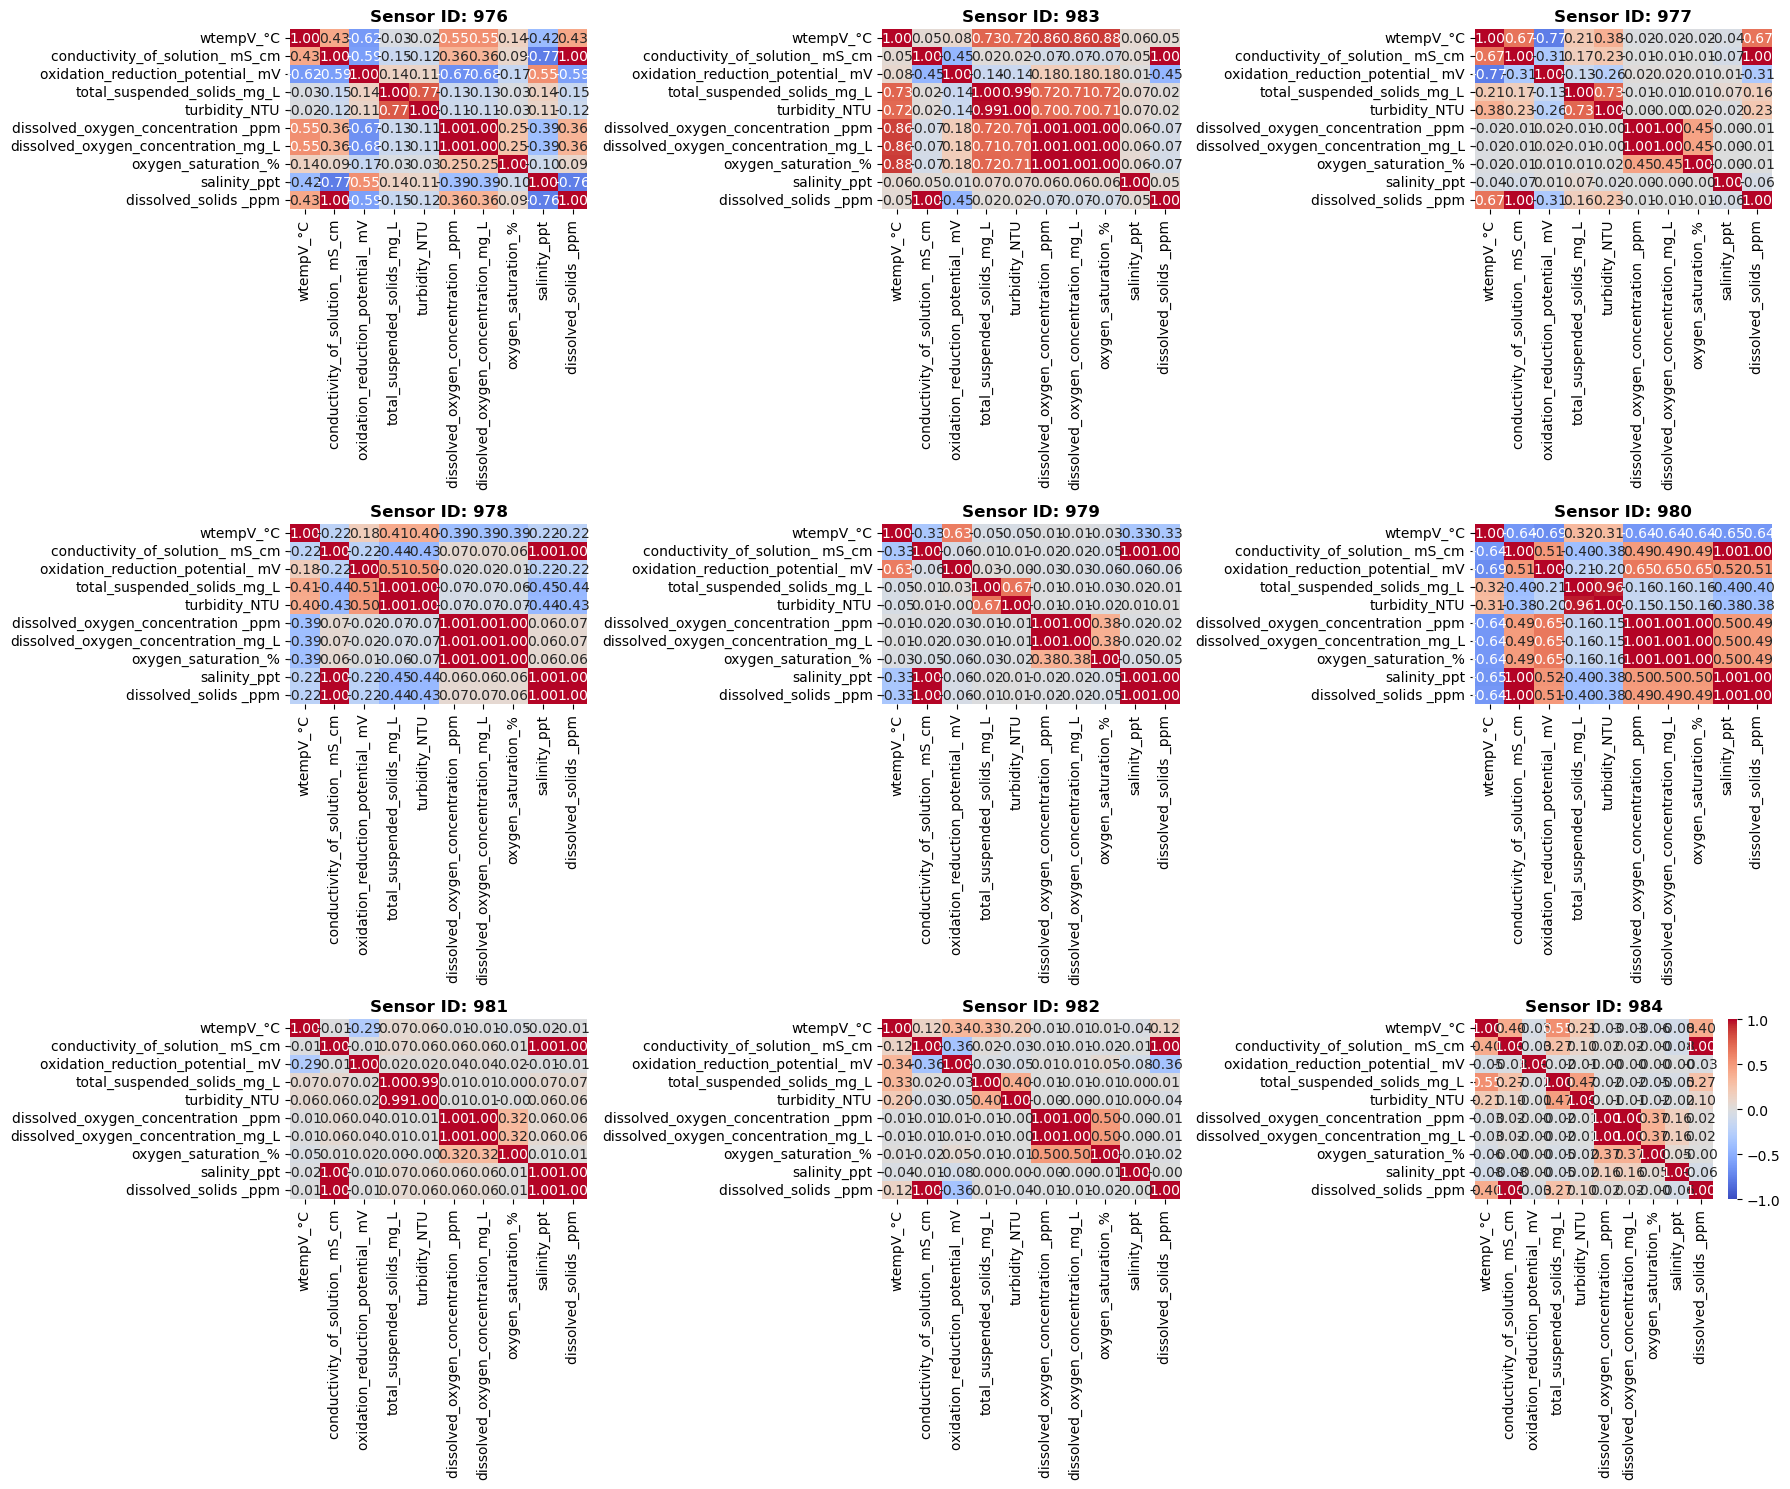

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Get unique sensor IDs
sensors = df['sensor_id'].unique()

for i, sensor_id in enumerate(sensors):
    sensor_df = df[df['sensor_id'] == sensor_id]
    corr = sensor_df[metrics].corr()
    
    sns.heatmap(
        corr, 
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1, 
        ax=axes[i],
        cbar=(i == 8) # Show colorbar only on the last plot to save space
    )
    axes[i].set_title(f'Sensor ID: {sensor_id}', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    display(x)
    pd.reset_option('display.max_rows')

In [35]:
print_full(df['conductivity_of_solution_ mS_cm'].value_counts())

conductivity_of_solution_ mS_cm
57402.49    129
56716.23     86
0.00         70
56293.33     60
57167.68     34
56927.30     23
57426.65     19
57287.71     19
56988.01     16
56771.48     13
57336.39     11
56799.76     11
57097.83     10
57668.88      8
57424.36      8
56334.53      7
50630.44      7
56953.81      7
56365.45      7
57109.43      6
56729.14      6
56886.98      6
57278.35      6
56873.60      6
56894.24      5
56899.02      5
56929.46      5
57166.73      5
56628.50      5
57127.37      4
57393.64      4
57447.44      4
56834.64      4
56840.98      4
57432.76      4
56626.48      4
57975.84      4
56845.19      4
57171.87      4
57419.48      4
57383.00      3
54544.58      3
57357.33      3
55867.46      3
57291.90      3
56878.27      3
57148.79      3
57413.39      3
56812.31      3
58161.57      3
56800.71      3
56876.64      3
57155.32      3
56806.41      3
56864.96      3
56901.57      3
56769.79      3
57059.67      3
57060.79      3
56726.30      3
56541.25